##**Notebook PC#12**

## Generative Adversarial Networks for the MNIST dataset.

This material is partially based on [this content](https://github.com/eriklindernoren/Keras-GAN/blob/master/gan/gan.py), with corrections and updates.

Professor: Fernando J. Von Zuben <BR>
Cursos: IA353A / EG453A (FEEC/Unicamp) - 1s2026 <BR>
Aluno(a): João Lucas Morais Ortiz RA: 297611<BR>
Aluno(a): Daniele Souza Gonçalves RA: 24802<BR>

In [1]:
from __future__ import print_function, division

from keras.datasets import mnist
from keras.layers import Input, Dense, Reshape, Flatten, Dropout
from keras.layers import BatchNormalization, Activation, ZeroPadding2D
from keras.layers import ReLU
from keras.layers import UpSampling2D, Conv2D
from keras.models import Sequential, Model
from keras.optimizers import Adam

import matplotlib.pyplot as plt

import sys

import numpy as np

import matplotlib.image as mpimg

import os

In [2]:
class GAN():
    def __init__(self):
        self.img_rows = 28
        self.img_cols = 28
        self.channels = 1
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = 100

        optimizer_d = Adam(0.0002, 0.5)
        optimizer_g = Adam(0.0002, 0.5)

        # Build and compile the discriminator
        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy', optimizer=optimizer_d, metrics=['accuracy'])

        # Build the generator
        self.generator = self.build_generator()

        # The generator takes noise as input and generates imgs
        z = Input(shape=(self.latent_dim,))
        img = self.generator(z)

        # For the combined model we will only train the generator
        self.discriminator.trainable = False

        # The discriminator takes generated images as input and determines validity
        validity = self.discriminator(img)

        # The combined model  (stacked generator and discriminator)
        # Trains the generator to fool the discriminator
        self.combined = Model(z, validity)
        self.combined.compile(loss='binary_crossentropy', optimizer=optimizer_g)

    def build_generator(self):

        model = Sequential()

        #model.add(Dense(256, input_shape=(self.latent_dim,)))
        model.add(Input(shape=(self.latent_dim,)))
        model.add(Dense(256))
        model.add(ReLU())
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(512))
        model.add(ReLU())
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(1024))
        model.add(ReLU())
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(int(np.prod(self.img_shape)), activation='tanh')) # Cast to int
        model.add(Reshape(self.img_shape))

        model.summary()

        noise = Input(shape=(self.latent_dim,))
        img = model(noise)

        return Model(noise, img)

    def build_discriminator(self):
        model = Sequential()
        model.add(Input(shape=self.img_shape))
        model.add(Flatten())
        model.add(Dense(512))
        model.add(ReLU())
        model.add(Dense(256))
        model.add(ReLU())
        model.add(Dense(1, activation='sigmoid'))
        model.summary()

        img = Input(shape=self.img_shape)
        validity = model(img)

        return Model(img, validity)

    def train(self, epochs, batch_size=128, sample_interval=50):

        # Load the dataset
        (X_train, _), (_, _) = mnist.load_data()

        # Rescale -1 to 1
        X_train = X_train / 127.5 - 1.
        X_train = np.expand_dims(X_train, axis=3)

        d_losses = []
        d_accuracies = []
        g_losses = []

        # Adversarial ground truths
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        for epoch in range(epochs):

            # ---------------------
            #  Train Discriminator
            # ---------------------

            # Select a random batch of images
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            imgs = X_train[idx]

            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))

            # Generate a batch of new images
            gen_imgs = self.generator.predict(noise, verbose=0)

            self.discriminator.trainable = True

            # Train the discriminator
            d_loss_real = self.discriminator.train_on_batch(imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            # ---------------------
            #  Train Generator
            # ---------------------

            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))

            self.discriminator.trainable = False

            # Train the generator (to have the discriminator label samples as valid)
            g_loss = self.combined.train_on_batch(noise, valid)

            d_losses.append(d_loss[0])
            d_accuracies.append(100*d_loss[1])
            g_losses.append(g_loss)

            # Plot the progress
            if epoch % 100 == 0:
                print ("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[1], g_loss))

            # If at save interval => save generated image samples
            if epoch % sample_interval == 0:
                self.sample_images(epoch)

        return d_losses, d_accuracies, g_losses

    def sample_images(self, epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise, verbose=0)

        # Rescale images 0 - 1
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt, :,:,0], cmap='gray')
                axs[i,j].axis('off')
                cnt += 1
        fig.savefig("%d.png" % epoch) # Please, define the working directory appropriately
        plt.close()

In [3]:
%%time
gan = GAN()
d_losses, d_accuracies, g_losses = gan.train(epochs=20001, batch_size=128, sample_interval=1000)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
0 [D loss: 0.993210, acc.: 4.30%] [G loss: 0.704516]
100 [D loss: 0.050776, acc.: 98.21%] [G loss: 3.899102]
200 [D loss: 0.157955, acc.: 93.50%] [G loss: 4.003478]
300 [D loss: 0.242982, acc.: 88.41%] [G loss: 3.591275]
400 [D loss: 0.292286, acc.: 85.22%] [G loss: 3.284533]
500 [D loss: 0.329611, acc.: 82.72%] [G loss: 3.075997]
600 [D loss: 0.374791, acc.: 79.17%] [G loss: 2.805467]
700 [D loss: 0.413362, acc.: 76.13%] [G loss: 2.526492]
800 [D loss: 0.438592, acc.: 75.07%] [G loss: 2.318280]
900 [D loss: 0.456891, acc.: 74.55%] [G loss: 2.167537]
1000 [D loss: 0.470018, acc.: 74.14%] [G loss: 2.052550]
1100 [D loss: 0.481478, acc.: 73.74%] [G loss: 1.961341]
1200 [D loss: 0.490624, acc.: 73.49%] [G loss: 1.883889]
1300 [D loss: 0.499313, acc.: 73.07%] [G loss: 1.814259]
1400 [D loss: 0.506766, acc.: 72.70%] [G loss: 1.753831]
1500 [D loss: 0.511464, acc.: 72.72%] [G loss: 1.707672]
1600 [D loss: 0.516549, acc.: 72.51%] [G loss: 1.6

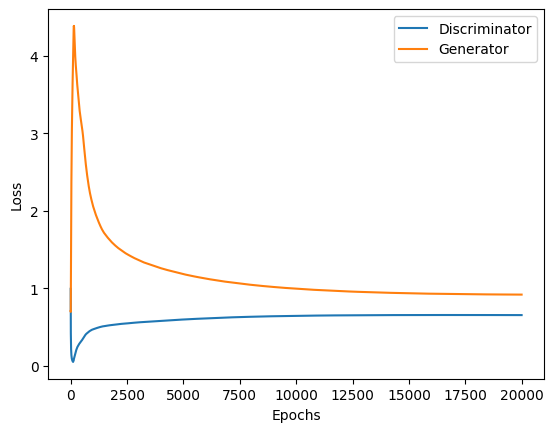

In [4]:
##
## Visualizing training losses
##
import matplotlib.pyplot as plt

plt.plot(d_losses, label='Discriminator')
plt.plot(g_losses, label='Generator')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

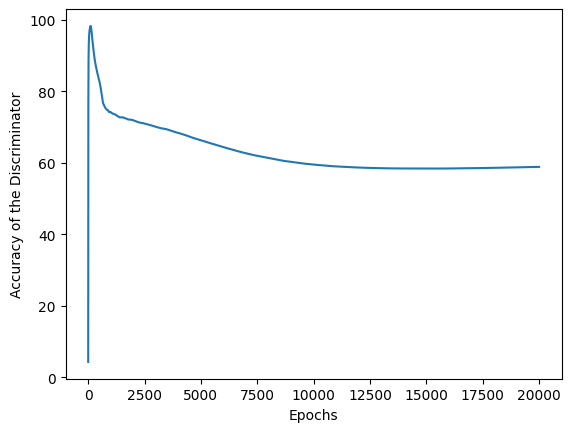

In [5]:
##
## Visualizing discriminator accuracy evolution
##
plt.plot(d_accuracies)
plt.xlabel('Epochs')
plt.ylabel('Accuracy of the Discriminator')
plt.show()

<font color="green">
Atividade (a) <br>
Explique o motivo pelo qual a evolução do desempenho das máquinas generativa e discriminativa é coerente com o esperado num cenário de treinamento bem-sucedido de uma GAN.<br>
</font>

**Resposta:**

A evolução observada nos gráficos de loss e acurácia é coerente com um treinamento bem-sucedido de GAN pelos seguintes motivos:

**1. Comportamento das Losses:**
- **Discriminador**: Começa com loss ~0.99 (época 0, quando ainda está "confuso"), cai rapidamente para ~0.05 (época 100, quando aprende a distinguir ruído de imagens reais), e então sobe gradualmente até estabilizar em ~0.65. Este aumento indica que G está melhorando e dificultando o trabalho de D.
- **Gerador**: Começa com loss ~0.70 (época 0), sobe para ~4.0 (épocas 100-200, quando D aprende a rejeitá-lo facilmente), e então decresce continuamente até estabilizar em ~0.92. Esta queda indica que G está aprendendo a enganar D.
- **Convergência**: As losses se aproximam ao longo do treinamento (D: 0.65, G: 0.92), sinalizando equilíbrio no jogo adversarial.

**2. Acurácia do Discriminador:**
- **Época 0 (~4%)**: D está inicialmente confuso (pesos aleatórios).
- **Época 100 (~98%)**: D aprende rapidamente a distinguir ruído puro de imagens reais.
- **Queda gradual**: À medida que G melhora, D tem mais dificuldade — a acurácia cai de 98% para ~59% ao longo de 20.000 épocas.
- **Estabilização (~58-59%)**: Este valor ligeiramente acima de 50% é característico de treinamento bem-sucedido. D ainda consegue distinguir um pouco melhor que o acaso, mas G produz imagens suficientemente realistas para confundi-lo frequentemente.

**3. Por que ~59% e não exatamente 50%?**
O equilíbrio perfeito de Nash (50%) é teórico. Na prática, pequenas imperfeições nas imagens geradas permitem que D mantenha uma leve vantagem. Isso é saudável — indica que D ainda fornece gradientes úteis para G continuar melhorando, evitando o colapso do treinamento.

**Sinais de treinamento MAL-sucedido** (que NÃO observamos aqui):
- Loss de G explodindo ou oscilando violentamente → mode collapse
- Acurácia de D permanecendo em ~100% → G não está aprendendo
- Acurácia de D caindo para ~50% muito rapidamente → possível instabilidade

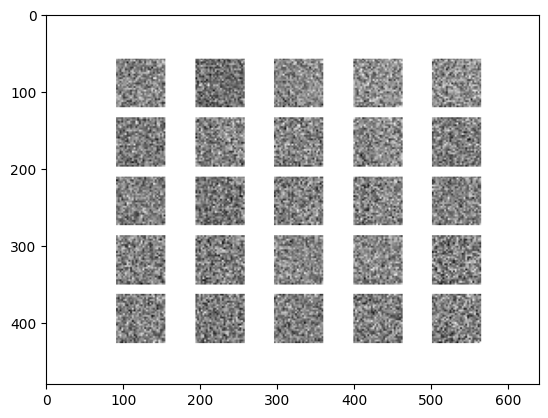

In [6]:
image_path = os.path.join(os.getcwd(), "0.png")
image = mpimg.imread(image_path)
plt.imshow(image)
plt.show()

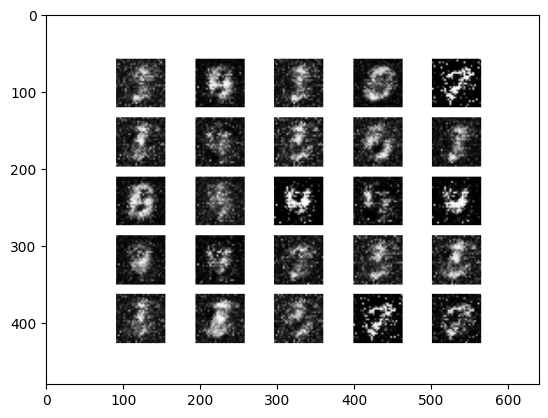

In [7]:
image_path = os.path.join(os.getcwd(), "1000.png")
image = mpimg.imread(image_path)
plt.imshow(image)
plt.show()

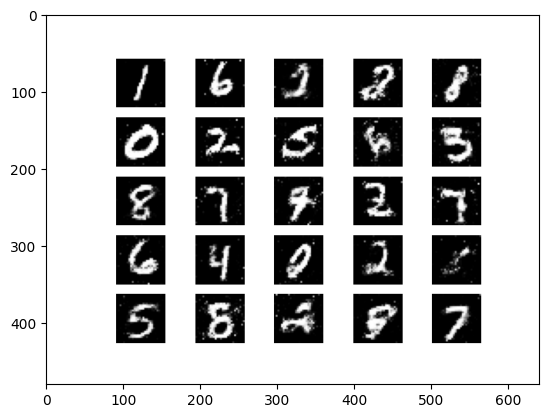

In [8]:
image_path = os.path.join(os.getcwd(), "10000.png")
image = mpimg.imread(image_path)
plt.imshow(image)
plt.show()

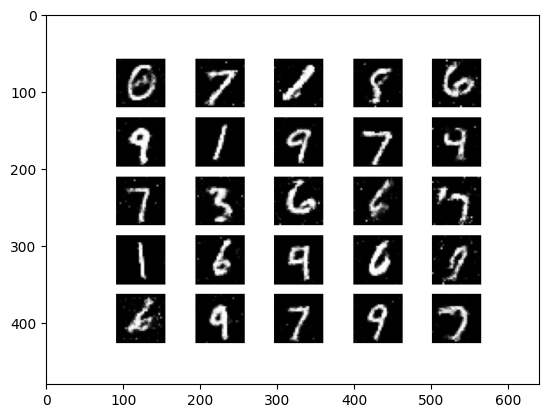

In [9]:
image_path = os.path.join(os.getcwd(), "20000.png")
image = mpimg.imread(image_path)
plt.imshow(image)
plt.show()

<font color="green">
Atividade (b) <br>
Explique como é obtida cada uma das 4 figuras acima.<br>
</font>

**Resposta:**

As 4 figuras são geradas pela função `sample_images()` em diferentes épocas do treinamento (0, 1000, 10000, 20000). O processo de geração de cada figura é:

**1. Amostragem do espaço latente:**
```python
noise = np.random.normal(0, 1, (25, 100))
```
São amostrados 25 vetores de ruído de uma distribuição normal padrão (média=0, desvio=1), cada um com 100 dimensões (`latent_dim=100`). Este espaço latente é o "espaço de códigos" que o Gerador aprendeu a mapear para imagens.

**2. Passagem pelo Gerador:**
```python
gen_imgs = self.generator.predict(noise)
```
Cada vetor de ruído passa pela rede geradora (Dense 256 → 512 → 1024 → 784 → Reshape 28×28), produzindo uma imagem 28×28 pixels.

**3. Reescalonamento:**
```python
gen_imgs = 0.5 * gen_imgs + 0.5
```
As imagens são convertidas do intervalo [-1, 1] (saída da ativação `tanh`) para [0, 1] (adequado para visualização).

**4. Visualização em grid 5×5:**
As 25 imagens são organizadas em uma grade e salvas como arquivo PNG.

**Evolução visual esperada:**
- **Época 0**: Ruído puro — o Gerador ainda não aprendeu nada, produz padrões aleatórios sem estrutura.
- **Época 1000**: Estruturas emergentes — começam a aparecer formas arredondadas e traços que lembram vagamente dígitos.
- **Época 10000**: Dígitos reconhecíveis — a maioria das imagens já se parece com números, embora alguns ainda apresentem artefatos.
- **Época 20000**: Dígitos bem definidos — imagens de alta qualidade, comparáveis aos dígitos reais do MNIST.

---

**Como obter um Gerador Controlado?**

A GAN implementada é **não-condicional** — o dígito gerado depende de qual região do espaço latente o ruído cai. Podemos explorar isso mapeando as **bacias de geração**: regiões do espaço de 100 dimensões que produzem cada dígito.

A abordagem consiste em:
1. Gerar muitos vetores de ruído aleatórios
2. Passar pelo Gerador para obter imagens
3. Classificar cada imagem (usando um classificador auxiliar treinado no MNIST como fizemos, ou rotular manualmente)
4. Projetar o espaço latente em 2D (via PCA) e colorir por dígito gerado

Isso revela as **fronteiras de transição** entre as bacias — e permite encontrar vetores de ruído que consistentemente geram um dígito específico. Também podemos **interpolar** entre dois vetores de ruído para visualizar a transição suave entre dígitos ao cruzar fronteiras.

Veja a implementação na célula seguinte.

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9013 - loss: 0.3593
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9516 - loss: 0.1685
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9661 - loss: 0.1193
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0921
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0735


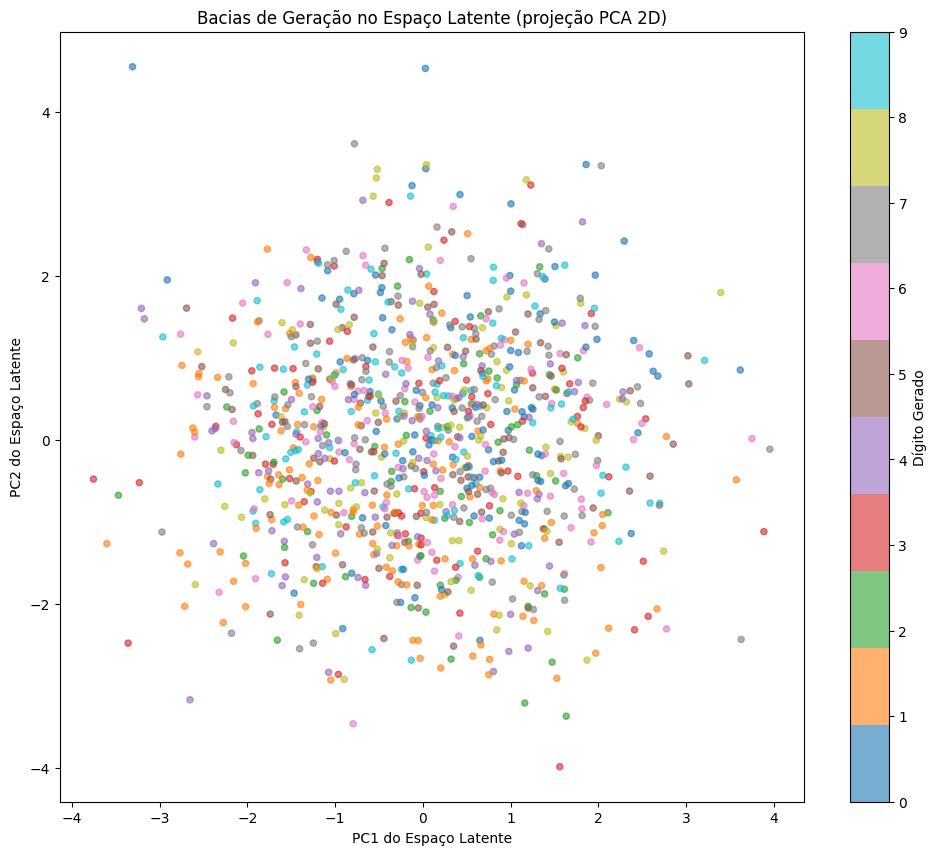

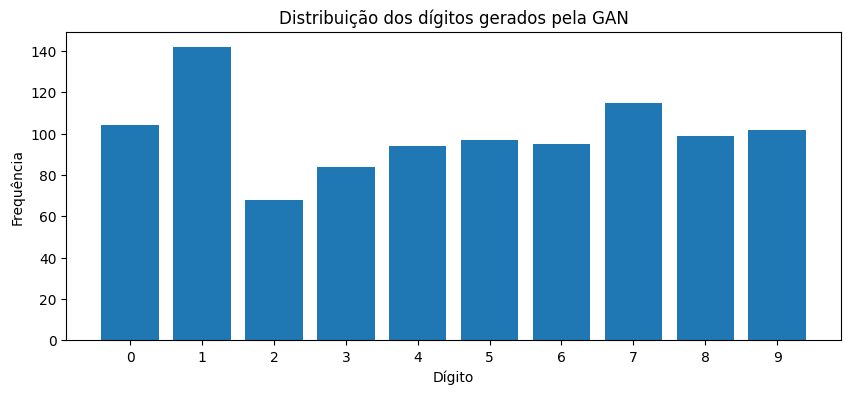

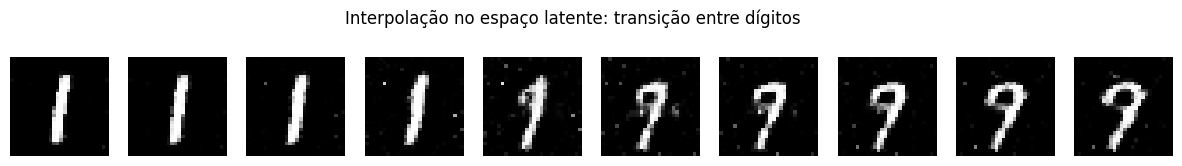

In [11]:
##
## Exploração do Espaço Latente - Mapeando as Bacias de Geração
##

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# Treinar um classificador simples para identificar os dígitos gerados
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

classifier = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
classifier.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)

# Gerar muitos ruídos e classificar as imagens resultantes
n_samples = 1000
noise_samples = np.random.normal(0, 1, (n_samples, 100))

# Gerar imagens com a GAN treinada
gen_imgs = gan.generator.predict(noise_samples, verbose=0)
gen_imgs_flat = (0.5 * gen_imgs.reshape(n_samples, 784) + 0.5)  # Rescale [0,1]

# Classificar cada imagem gerada
predictions = classifier.predict(gen_imgs_flat, verbose=0)
predicted_digits = np.argmax(predictions, axis=1)

# Reduzir o espaço latente de 100D para 2D com PCA para visualização
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
noise_2d = pca.fit_transform(noise_samples)

# Plotar as bacias de geração
plt.figure(figsize=(12, 10))
scatter = plt.scatter(noise_2d[:, 0], noise_2d[:, 1], c=predicted_digits, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Dígito Gerado')
plt.xlabel('PC1 do Espaço Latente')
plt.ylabel('PC2 do Espaço Latente')
plt.title('Bacias de Geração no Espaço Latente (projeção PCA 2D)')
plt.show()

# Distribuição de dígitos gerados
unique, counts = np.unique(predicted_digits, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(unique, counts)
plt.xlabel('Dígito')
plt.ylabel('Frequência')
plt.title('Distribuição dos dígitos gerados pela GAN')
plt.xticks(range(10))
plt.show()

#E para visualizar interpolação entre regiões (transição entre dígitos):

##
## Interpolação no espaço latente - visualizando transições
##

# Pegar dois ruídos que geram dígitos diferentes
idx_digit_1 = np.where(predicted_digits == 1)[0][0]
idx_digit_7 = np.where(predicted_digits == 7)[0][0]

z1 = noise_samples[idx_digit_1]
z2 = noise_samples[idx_digit_7]

# Interpolar linearmente entre eles
n_steps = 10
interpolations = np.array([z1 + (z2 - z1) * t for t in np.linspace(0, 1, n_steps)])

# Gerar imagens ao longo da interpolação
interp_imgs = gan.generator.predict(interpolations, verbose=0)
interp_imgs = 0.5 * interp_imgs + 0.5

# Plotar a transição
fig, axs = plt.subplots(1, n_steps, figsize=(15, 2))
for i in range(n_steps):
    axs[i].imshow(interp_imgs[i, :, :, 0], cmap='gray')
    axs[i].axis('off')
plt.suptitle('Interpolação no espaço latente: transição entre dígitos')
plt.show()

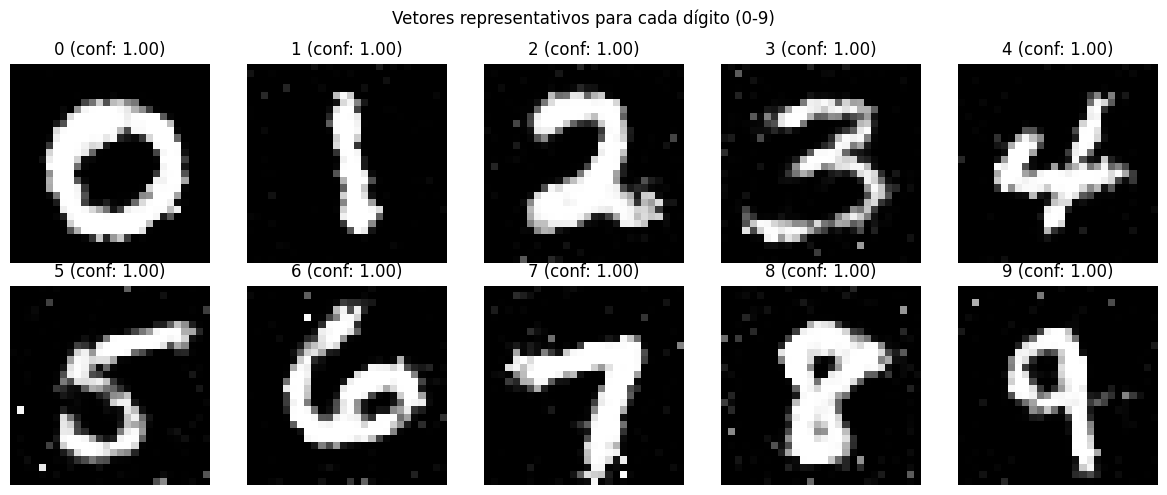


### Vetores de ruído representativos (copie para reutilizar) ###

digit_vectors = {
    0: np.array([-1.580964, -0.984958, -1.538639,  1.583203,  0.22477 ,  0.641719,  1.974181,  0.071592, -2.26118 , -0.34654 , -0.203095, -0.871416,  1.233395,  0.243612, -0.266117, -1.054721,  1.537086, -1.839475,
 -0.378189, -0.101365,  0.605364, -0.690157, -1.062751, -0.099537, -1.087732, -0.335947,  0.157255, -0.226928, -0.120734, -1.004836, -1.444265,  0.684715,  2.717114,  1.243447, -1.185055,  1.791467,
  0.054123,  1.129175,  0.393904, -0.484708,  0.119279,  1.355256,  0.834068, -1.764726,  2.375189,  1.630164,  1.351777, -0.310818, -0.255672,  0.349602,  0.462859, -0.69858 ,  0.495742, -0.564502,
 -0.232475, -0.986019,  1.482891,  0.267221,  1.606861, -0.533419, -0.473928,  1.559027,  1.139341,  0.419599,  0.195425,  0.37201 , -0.857586,  1.569198,  1.377022,  0.376444,  0.585804, -0.687918,
  0.839596, -0.044862, -1.593956, -0.767025,  0.66322 ,  0.032777, -0.148527, -0.263136, -0.206237,  0.

In [12]:
##
## Extraindo vetores representativos para cada dígito (0-9)
##

# Encontrar o melhor vetor de ruído para cada dígito (maior confiança do classificador)
representative_vectors = {}
representative_confidence = {}

for digit in range(10):
    # Índices onde o classificador previu este dígito
    digit_indices = np.where(predicted_digits == digit)[0]
    
    if len(digit_indices) > 0:
        # Pegar as confianças para este dígito
        confidences = predictions[digit_indices, digit]
        # Escolher o de maior confiança
        best_idx = digit_indices[np.argmax(confidences)]
        representative_vectors[digit] = noise_samples[best_idx]
        representative_confidence[digit] = predictions[best_idx, digit]
    else:
        print(f"Dígito {digit} não encontrado nas amostras!")

# Mostrar os vetores representativos gerando as imagens
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    row, col = digit // 5, digit % 5
    if digit in representative_vectors:
        z = representative_vectors[digit].reshape(1, -1)
        img = gan.generator.predict(z, verbose=0)
        img = 0.5 * img + 0.5
        axs[row, col].imshow(img[0, :, :, 0], cmap='gray')
        axs[row, col].set_title(f'{digit} (conf: {representative_confidence[digit]:.2f})')
    axs[row, col].axis('off')
plt.suptitle('Vetores representativos para cada dígito (0-9)')
plt.tight_layout()
plt.show()

# Salvar os vetores para uso futuro
print("\n### Vetores de ruído representativos (copie para reutilizar) ###\n")
print("digit_vectors = {")
for digit in range(10):
    if digit in representative_vectors:
        vec_str = np.array2string(representative_vectors[digit], separator=', ', max_line_width=200, precision=6)
        print(f"    {digit}: np.array({vec_str}),")
print("}")